# 17-Latent Diffusion Models

If you attempt to deploy the standard Pixel Diffusion model we built in Lesson 16 to generate a $1024 \times 1024$ HD image, you will hit a massive computational brick wall.

A $1024 \times 1024$ RGB image contains **3,145,728 numbers**. During the reverse generation process, the U-Net must calculate the thermodynamic noise for all 3 million numbers, and it must do this *1,000 separate times* (for 1,000 timesteps) just to generate one single image. Training this requires clusters of GPUs running for months because pixel space is astronomically high-dimensional.

In 2022, researchers at LMU Munich published a paper that changed the world: *High-Resolution Image Synthesis with Latent Diffusion Models*. They found a way to bypass the 3-million-pixel bottleneck completely by operating in an alternate mathematical dimension.

Let's set up our PyTorch environment to master the architecture of modern Generative AI.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from skimage import data
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Latent Diffusion Architecture Environment Ready.")

✅ PyTorch Latent Diffusion Architecture Environment Ready.


# 1. The Perceptual Compressor (The VAE)

To understand the genius of Latent Diffusion, we must understand the flaw of Pixel Diffusion.

Images contain massive amounts of **Imperceptible High-Frequency Detail**. Look at a picture of a forest. There are millions of pixels dedicated solely to rendering the microscopic texture of individual tree bark. When you run Diffusion in pixel space, the U-Net wastes 80% of its massive computing power meticulously trying to denoise random bark textures that the human eye barely even registers, instead of focusing on the semantic concept of the "forest".

To fix this, LDM utilizes the **Variational Autoencoder (VAE)** we built in Lesson 13.

Before the Diffusion process even begins, we train a massive VAE to compress images into a highly condensed mathematical realm called the **Latent Space**.

* We take a $512 \times 512 \times 3$ image (786,432 numbers).
* We pass it through the VAE Encoder ($\mathcal{E}$).
* It is mathematically crushed into a $64 \times 64 \times 4$ latent tensor (16,384 numbers).

This is a **48x mathematical reduction in data**. The latent tensor ($z$) contains no raw pixels, no bark textures, and no lighting artifacts. It is a pure, dense mathematical matrix of *semantic meaning*.

**The Paradigm Shift:** We do not run Diffusion on pixels anymore. We inject the Gaussian thermodynamic noise directly into the $64 \times 64$ latent tensor. We train the U-Net to denoise the $64 \times 64$ latent tensor. Once the U-Net has generated a clean latent tensor from pure noise, we pass it through the VAE Decoder ($\mathcal{D}$) to blow it back up into a flawless $512 \times 512$ pixel image.

# 2. Text Conditioning (Cross-Attention)

We can now generate images 48x faster. But how do we tell the network *what* to generate? How do we type "An astronaut riding a horse" and force the U-Net to generate exactly that?

We must mathematically fuse Natural Language Processing (NLP) with Computer Vision. We do this using **CLIP (Contrastive Language-Image Pre-training)** and **Cross-Attention**.

1. **Text Encoding ($\tau_\theta$)**: We take the user's text prompt and pass it through the CLIP text encoder (a Transformer). It converts the words into a $1 \times 77 \times 768$ matrix of text embeddings (77 words, 768 dimensions of semantic meaning).
2. **Cross-Attention**: Inside the U-Net, we use the Attention mechanism we learned in Lesson 11, but with an architectural twist.
* The **Queries ($Q$)** come from the visual image (the noisy latent tensor).
* The **Keys ($K$)** and **Values ($V$)** come from the CLIP text embeddings.



$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Mathematically, the visual pixels "query" the text words. A cluster of pixels in the center of the noise matrix might ask, *"I am near the middle, what should I be?"* The text embedding for the word "astronaut" responds, strongly binding its mathematical value to those specific pixels.

# 3. The LDM Mathematical Objective

The entire architecture can be summarized in one beautiful, overarching equation:

$$L_{LDM} = \mathbb{E}_{\mathcal{E}(x), y, \epsilon \sim \mathcal{N}(0,1), t} \left[ ||\epsilon - \epsilon_\theta(z_t, t, \tau_\theta(y))||^2_2 \right]$$

* $\mathcal{E}(x)$: The VAE compressing the real image $x$ into the latent space $z$.
* $\epsilon$: The true random noise injected into the latent space.
* $y$: The text prompt (e.g., "An astronaut").
* $\tau_\theta(y)$: The CLIP text encoder translating the prompt into math.
* $\epsilon_\theta$: The U-Net predicting the noise inside the latent space.

# 4. Architecting the LDM Pipeline in PyTorch

Let's simulate the exact enterprise tensor transformations of the Latent Diffusion pipeline using our real data. We will pass Eileen Collins through a simulated VAE, inject text via Cross-Attention, track the mathematical shapes, and visually inspect the Latent dimensions.

1. Raw Pixel Space Image: torch.Size([1, 3, 512, 512]) (786,432 numbers)

--- 🗜️ VAE Compression ---
2. Latent Space Tensor (z): torch.Size([1, 4, 64, 64]) (16,384 numbers)
Insight: The U-Net will now operate exclusively on this tiny [1, 4, 64, 64] tensor, ignoring raw pixels entirely!

--- 📝 NLP to Math Translation ---
User Prompt: 'An astronaut wearing a white space suit'
3. CLIP Text Embeddings:    torch.Size([1, 77, 768])

--- ⚡ Cross-Attention Fusion ---
4. Conditioned Visual Data: torch.Size([1, 4096, 256])
Success! The U-Net evaluated the 4,096 latent visual patches and mapped them against the 77 text words. The text prompt is now mathematically injected into the visual noise!


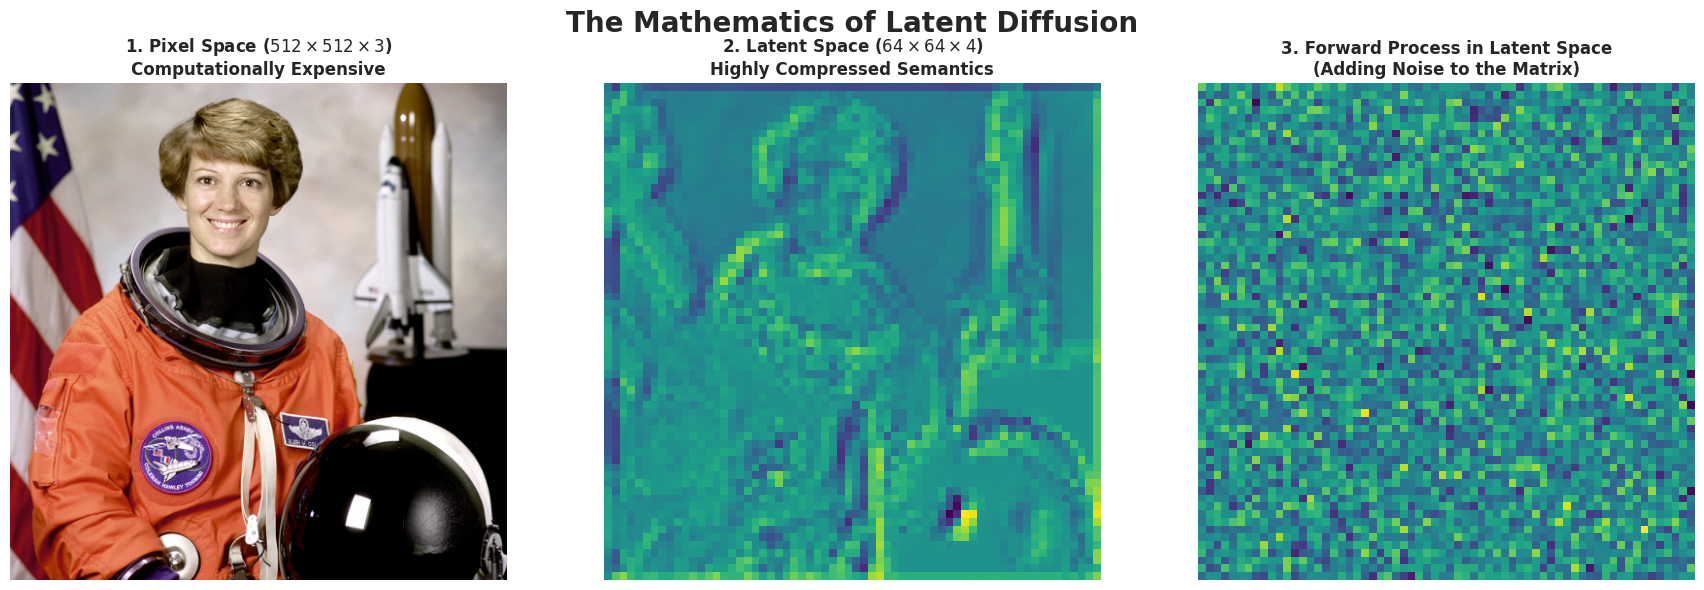

In [2]:
# 1. Fetch and Preprocess the Target Image
numpy_img = data.astronaut()
# Standard Stable Diffusion Resolution is usually 512x512
resized_img = resize(numpy_img, (512, 512), anti_aliasing=True)

# Convert to PyTorch Tensor [Batch, Channels, Height, Width]
real_image = torch.tensor(resized_img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
print(f"1. Raw Pixel Space Image: {real_image.shape} (786,432 numbers)")

# 2. Architect the VAE Encoder (The Perceptual Compressor)
class VAE_Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Simulating the dramatic 8x spatial compression (512 -> 256 -> 128 -> 64)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # 256x256
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 128x128
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 64x64
            nn.ReLU(),
            nn.Conv2d(64, 4, kernel_size=3, padding=1)             # Final Latent Channels (4)
        )
    def forward(self, x):
        return self.encoder(x)

vae_encoder = VAE_Encoder()
# We use torch.no_grad() because we are simulating the forward pass without training
with torch.no_grad():
    latent_tensor = vae_encoder(real_image)

print("\n--- 🗜️ VAE Compression ---")
print(f"2. Latent Space Tensor (z): {latent_tensor.shape} (16,384 numbers)")
print("Insight: The U-Net will now operate exclusively on this tiny [1, 4, 64, 64] tensor, ignoring raw pixels entirely!")

# 3. Architect Text Conditioning (Simulating CLIP)
print("\n--- 📝 NLP to Math Translation ---")
prompt = "An astronaut wearing a white space suit"
print(f"User Prompt: '{prompt}'")

# CLIP typically outputs 77 tokens (words/sub-words), each with 768 dimensions of meaning
# Shape: [Batch, Sequence_Length, Embedding_Dim]
text_embeddings = torch.randn(1, 77, 768) 
print(f"3. CLIP Text Embeddings:    {text_embeddings.shape}")

# 4. Architect the Cross-Attention U-Net Core
class CrossAttentionBlock(nn.Module):
    def __init__(self, visual_dim=4, text_dim=768, hidden_dim=256):
        super().__init__()
        # Projecting visual patches to Queries
        self.to_q = nn.Linear(visual_dim, hidden_dim)
        # Projecting text embeddings to Keys and Values
        self.to_k = nn.Linear(text_dim, hidden_dim)
        self.to_v = nn.Linear(text_dim, hidden_dim)
        
    def forward(self, visual_latent, text_embeds):
        # Flatten spatial dimensions to a sequence of patches: [1, 4, 64, 64] -> [1, 4096, 4]
        b, c, h, w = visual_latent.shape
        visual_seq = visual_latent.view(b, c, h * w).transpose(1, 2)
        
        # Q comes from the Image
        Q = self.to_q(visual_seq)     # [1, 4096, 256]
        
        # K and V come from the Text!
        K = self.to_k(text_embeds)    # [1, 77, 256]
        V = self.to_v(text_embeds)    # [1, 77, 256]
        
        # Mathematical Attention: Image queries the Text
        # scale = 1 / sqrt(hidden_dim)
        attention_scores = torch.bmm(Q, K.transpose(1, 2)) / (256 ** 0.5) # [1, 4096, 77]
        attention_weights = F.softmax(attention_scores, dim=-1)
        
        # Apply the text Values to the image
        conditioned_visuals = torch.bmm(attention_weights, V) # [1, 4096, 256]
        return conditioned_visuals

cross_attention = CrossAttentionBlock()

# Add standard Gaussian noise to the latent tensor to simulate timestep 't'
noisy_latent = latent_tensor + (torch.randn_like(latent_tensor) * 1.5)

# Fuse the noisy image with the text prompt!
with torch.no_grad():
    fused_data = cross_attention(noisy_latent, text_embeddings)

print("\n--- ⚡ Cross-Attention Fusion ---")
print(f"4. Conditioned Visual Data: {fused_data.shape}")
print("Success! The U-Net evaluated the 4,096 latent visual patches and mapped them against the 77 text words. The text prompt is now mathematically injected into the visual noise!")

# 5. Visualizing the Mathematical Domains
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("The Mathematics of Latent Diffusion", fontsize=20, fontweight='bold')

# Plot A: Pixel Space
axes[0].imshow(resized_img)
axes[0].set_title("1. Pixel Space ($512 \\times 512 \\times 3$)\nComputationally Expensive", fontweight='bold', fontsize=12)
axes[0].axis('off')

# Plot B: Simulated Latent Space Representation
# We take the first channel of our untrained Latent Tensor to visualize the mathematical abstraction
latent_viz = latent_tensor[0, 0, :, :].numpy()
axes[1].imshow(latent_viz, cmap='viridis')
axes[1].set_title("2. Latent Space ($64 \\times 64 \\times 4$)\nHighly Compressed Semantics", fontweight='bold', fontsize=12)
axes[1].axis('off')

# Plot C: Noisy Latent Space
noisy_latent_viz = noisy_latent[0, 0, :, :].numpy()
axes[2].imshow(noisy_latent_viz, cmap='viridis')
axes[2].set_title("3. Forward Process in Latent Space\n(Adding Noise to the Matrix)", fontweight='bold', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Latent Diffusion like **An Architect designing a skyscraper**:

* **Standard Pixel Diffusion (The Bricklayer)**: The builder goes to an empty lot. They pick up a single microscopic brick (a pixel). They ask, *"Based on the blueprint, does this brick go here?"* They place it. They move 1 inch to the right and repeat 3 million times. It takes 50 years to build the skyscraper.
* **The VAE (The Architectural Blueprint)**: The Architect does not deal with bricks. The Architect works purely on a small piece of paper (The Latent Space). A single sweeping line drawn in pencil ($64 \times 64$ tensor) conceptually represents 10,000 physical bricks. The Architect can erase and redraw the entire building in 5 minutes.
* **Cross-Attention (The Client Meeting)**: The client says, *"I want a Gothic Cathedral"* (Text Prompt / CLIP Embedding). The Architect takes their pencil, queries the client's words against the blueprint, and adjusts the structural lines on the paper to perfectly match the request.
* **The VAE Decoder (The Construction Crew)**: Once the Architect is perfectly happy with the pencil drawing (The Denoised Latent Space), they hand the $64 \times 64$ blueprint to a massive, highly efficient construction crew (The Decoder). The crew takes the conceptual lines and instantly translates them into 3 million physical bricks (The Final Output Image).